# Uniform semi-infinite PIKAN prediction

Train a separate semi-infinite PIKAN with uniform interior samples and uniform top-boundary samples, then evaluate and save its checkpoint.

In [1]:
from pathlib import Path
import sys
from importlib import reload
import matplotlib.pyplot as plt
import numpy as np
import torch

notebook_dir = Path.cwd().resolve()
repo_root = next((path for path in [notebook_dir, *notebook_dir.parents] if (path / 'utils').is_dir()), notebook_dir)
utilities_dir = repo_root / 'utils'
if str(utilities_dir) not in sys.path:
    sys.path.insert(0, str(utilities_dir))

import project_paths
import pinns
import pinns_semi_infinite
import semi_infinite
reload(semi_infinite)
reload(pinns)
reload(pinns_semi_infinite)
from pinns_semi_infinite import build_models_KAN, set_seed, train_dual_network_semi_inf
from semi_infinite import analytical_solution_semi_inf, coefficient_semi_inf, evaluate_model_semi_inf
set_seed(2)
torch.set_default_dtype(torch.float32)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

/home/orincon/miniconda3/envs/PIKAN-unbounded-domains-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [2]:
config = {
    'hidden_layers': 3,
    'hidden_units': 25,
    'grid_size': 5,
    'spline_order': 3,
    'adam_lr': 1e-3,
    'adam_iters': 2000,
    'lbfgs_iters': 2000,
    'sampling': 'uniform',
    'sigma': 5.5,
    'exp_scale': 4.0,
    'n_obs_u': 100,
    'n_boundary_u': 100,
    'n_obs_k': 100,
    'n_pde': 1000,
    'seed': 2,
    'pde_alpha': 0.5,
    'pde_beta': 5.0,
    'epsilon': 1.0,
    'train_domain': (-5.0, 5.0, -5.0, 0.0),
    'eval_domain': (-10.0, 10.0, -10.0, 0.0),
}
for name, value in config.items():
    print(f'{name}: {value}')

hidden_layers: 3
hidden_units: 25
grid_size: 5
spline_order: 3
adam_lr: 0.001
adam_iters: 2000
lbfgs_iters: 2000
sampling: uniform
sigma: 5.5
exp_scale: 4.0
n_obs_u: 100
n_boundary_u: 100
n_obs_k: 100
n_pde: 1000
seed: 2
pde_alpha: 0.5
pde_beta: 5.0
epsilon: 1.0
train_domain: (-5.0, 5.0, -5.0, 0.0)
eval_domain: (-10.0, 10.0, -10.0, 0.0)


In [3]:
model_u, model_k = build_models_KAN(device=device, hidden_layers=config['hidden_layers'], hidden_units=config['hidden_units'], grid_size=config['grid_size'], spline_order=config['spline_order'])
results_dir = project_paths.results_dir("individual_prediction")
history = train_dual_network_semi_inf(
    model_u, model_k,
    adam_lr=config['adam_lr'], adam_iters=config['adam_iters'], lbfgs_iters=config['lbfgs_iters'],
    verbose=True, print_every=100, save_every=100,
    lambda_pde_scheduler=True, adaptive_weights=True, alpha=7, update_every=100,
    regularization=False, sampling=config['sampling'], sigma=config['sigma'], exp_scale=config['exp_scale'],
    n_obs_u=config['n_obs_u'], n_boundary_u=config['n_boundary_u'], n_obs_k=config['n_obs_k'], n_pde=config['n_pde'],
    seed=config['seed'], save_results=True, base_dir=str(results_dir), run_name='pikan_semi_infinite_uniform',
    pde_alpha=config['pde_alpha'], pde_beta=config['pde_beta'], epsilon=config['epsilon'], device=device,
)


Training with Adam


/home/orincon/miniconda3/envs/PIKAN-unbounded-domains-env/lib/python3.12/site-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Adam     0 | Total=7.126e+00 | ObsU=4.764e-02 | ObsK=3.038e+00 | PDE=4.040e+01 | Ratio=63.78 | ErrU=1.000e+00 | ErrK=9.957e-01
V      = [0.048 3.038]
R      = [0. 1.]
ratio  = 63.78
lambda_u = 1.000
lambda_k = 52.648
lambda_pde = 0.100
Adam   100 | Total=4.208e+00 | ObsU=8.723e-02 | ObsK=2.506e-01 | PDE=3.870e+01 | Ratio=63.78 | ErrU=1.357e+00 | ErrK=2.876e-01
V      = [0.067 1.644]
R      = [0. 1.]
ratio  = 24.39
lambda_u = 1.000
lambda_k = 25.071
lambda_pde = 0.100
Adam   200 | Total=4.025e+00 | ObsU=8.715e-02 | ObsK=9.515e-03 | PDE=3.437e+01 | Ratio=24.39 | ErrU=1.344e+00 | ErrK=5.538e-02
V      = [0.074 1.099]
R      = [0. 1.]
ratio  = 14.86
lambda_u = 1.000
lambda_k = 18.400
lambda_pde = 0.100
Adam   300 | Total=6.188e-01 | ObsU=1.181e-02 | ObsK=2.950e-03 | PDE=5.330e+00 | Ratio=14.86 | ErrU=4.981e-01 | ErrK=3.108e-02
V      = [0.058 0.825]
R      = [0. 1.]
ratio  = 14.12
lambda_u = 1.000
lambda_k = 17.884
lambda_pde = 0.250
Adam   400 | Total=6.169e-01 | ObsU=6.534e-03 | ObsK=1.1

In [4]:
evaluation = evaluate_model_semi_inf(model_u=model_u, model_k=model_k, analytical_solution=analytical_solution_semi_inf, coefficient=coefficient_semi_inf, train_domain=config['train_domain'], eval_domain=config['eval_domain'], n_grid=400, alpha=config['pde_alpha'], beta=config['pde_beta'], epsilon=config['epsilon'], device=device, verbose=True)
metrics = {name: float(evaluation[name]) for name in ('err_u_global', 'err_k_global', 'err_u_inside', 'err_k_inside', 'err_u_outside', 'err_k_outside')}
metrics

Semi-infinite-domain spatial generalization (MAE)
u (global): 2.890e-02
k (global): 1.577e-01
u (inside): 3.997e-03
k (inside): 1.250e-03
u (outside): 3.720e-02
k (outside): 2.098e-01


{'err_u_global': 0.028901798557838556,
 'err_k_global': 0.1576793934715561,
 'err_u_inside': 0.003996963691537962,
 'err_k_inside': 0.0012496225980278691,
 'err_u_outside': 0.03720341017993875,
 'err_k_outside': 0.20982265042939882}

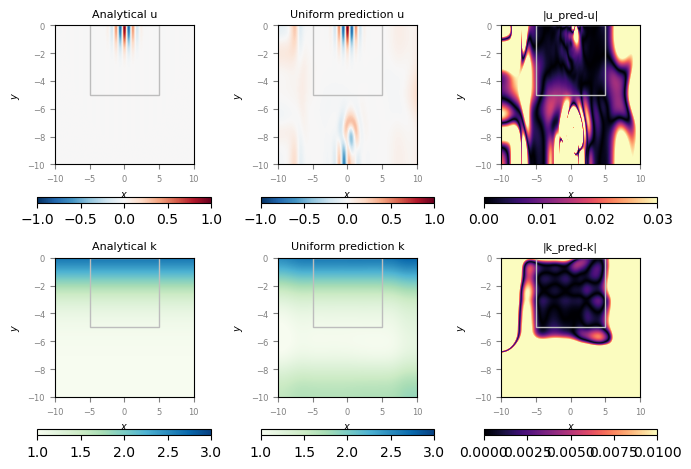

In [5]:
X, Y = evaluation['X'], evaluation['Y']
U_exact = analytical_solution_semi_inf(X, Y, config['pde_alpha'], config['pde_beta'])
K_exact = coefficient_semi_inf(X, Y, config['epsilon'])
U_pred, K_pred = evaluation['U_pred'], evaluation['K_pred']
fig, axes = plt.subplots(2, 3, figsize=(7, 4.8))
extent = [*config['eval_domain'][:2], *config['eval_domain'][2:]]
panels = [(U_exact, 'Analytical u', 'RdBu_r', -1, 1), (U_pred, 'Uniform prediction u', 'RdBu_r', -1, 1), (np.abs(U_pred-U_exact), '|u_pred-u|', 'magma', 0, 0.03), (K_exact, 'Analytical k', 'GnBu', 1, 3), (K_pred, 'Uniform prediction k', 'GnBu', 1, 3), (np.abs(K_pred-K_exact), '|k_pred-k|', 'magma', 0, 0.01)]
for axis, (values, title, cmap, vmin, vmax) in zip(axes.ravel(), panels):
    image = axis.imshow(values, extent=extent, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    axis.add_patch(plt.Rectangle((-5, -5), 10, 5, fill=False, edgecolor='#BDBDBD', linewidth=1.0))
    axis.set_box_aspect(1); axis.set_title(title, fontsize=8); axis.set_xlabel('$x$', fontsize=7); axis.set_ylabel('$y$', fontsize=7)
    axis.tick_params(labelsize=6, colors='gray'); fig.colorbar(image, ax=axis, orientation='horizontal', fraction=0.045, pad=0.18, aspect=28)
plt.tight_layout(); plt.show()

In [6]:
weights_path = results_dir / 'pikan_semi_infinite_uniform_weights.pt'
torch.save({'model_u': model_u.state_dict(), 'model_k': model_k.state_dict(), 'config': config, 'metrics': metrics}, weights_path)
print(f'Saved uniform checkpoint to: {weights_path}')

Saved uniform checkpoint to: /home/orincon/unbounded-domains/main/03_individual_prediction/results/pikan_semi_infinite_uniform_weights.pt
